# How to evaluate embeddings using linear algebra and analogies

This notebook studies one of the classical ways to evaluate word embeddings: the analogy task. The central idea is that some semantic and grammatical relations may be represented as directions in the embedding space. If this is true, then vector arithmetic should partially reproduce relations such as:



```text
Athens : Greece = Baghdad : Iraq
bad : worse = big : bigger
boy : girl = brother : sister
```

The notebook is therefore not only a coding exercise. It is also a diagnostic tool: it helps us understand whether the geometry learned by an embedding model contains meaningful relational structure.


## Conceptual background

The individual dimensions of a word vector usually do not have a direct human-readable interpretation. A single coordinate is rarely equivalent to a clean concept such as *gender*, *country*, *tense*, or *size*. What matters is the position of a word relative to other words in the embedding space.

For this reason, embeddings are often evaluated through distances, similarities, and vector differences. The analogy benchmark is based on the assumption that some relations correspond to approximately stable vector offsets. For instance, if the vector difference between *Greece* and *Athens* captures something like “country of a capital city”, then adding the same relational direction to *Baghdad* should lead us near *Iraq*.

This is an elegant and intuitive test, but it should not be overinterpreted. Passing analogy tests does not prove that an embedding model “understands” language. It only shows that some relations are encoded in a sufficiently linear and recoverable form.


## Imports

This section imports the libraries used throughout the notebook. `pandas` is used to load and manipulate the analogy dataset, `numpy` provides numerical utilities, and `matplotlib` together with `seaborn` is used for visualization. The `%matplotlib inline` directive ensures that plots appear directly inside the notebook.


In [1]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Import done!")

Import done!


## Settings

The notebook applies a simple visual style for plots, configures the display format for floating-point numbers, and fixes the NumPy random seed. Even though the present section of the notebook is mostly deterministic, setting the random seed is a good habit in computational notebooks because it makes later experiments easier to reproduce.


In [2]:
sns.set_style('white')
pd.set_option('float_format', '{:,.2f}'.format)
np.random.seed(42)

## Location of the analogy dataset

The variable `analogy_path` points to the text file containing the analogy benchmark. The file is expected to contain two types of rows. Rows beginning with `:` define a category, while all other rows contain four words representing one analogy.

For example, a category line may look like:

```text
: capital-common-countries
```

while an analogy line may look like:

```text
athens greece baghdad iraq
```


In [3]:
analogy_path = Path('data', 'analogies-en.txt')

## Utility function for timing

The function `format_time` converts a time interval measured in seconds into a more readable `hours:minutes:seconds` format. This is useful in embedding evaluation because nearest-neighbor search over a large vocabulary can become computationally expensive. Even if this function is not central to the current data preparation step, it is useful infrastructure for later evaluation routines.


In [4]:
def format_time(t):
    m, s = divmod(t, 60)
    h, m = divmod(m, 60)
    return f'{h:02.0f}:{m:02.0f}:{s:02.0f}'

## Evaluation dataset: analogies

Before evaluating an embedding model, the benchmark file must be transformed into a clean tabular structure. Each row should contain one analogy and the category to which that analogy belongs.

The desired final structure is:

```text
category | a | b | c | d
```

where the analogy means:

```text
a is to b as c is to d
```

For example:

```text
athens is to greece as baghdad is to iraq
```


### Parsing the analogy file

The following cell reads the raw analogy file and transforms it into a clean dataframe. This version is compatible with modern versions of pandas because it avoids the deprecated `squeeze=True` argument.

The key point is that the category is not stored on every line of the original file. It appears only when a new block begins. Therefore, the code first creates a `category_per_line` series by forward-filling the most recent category. Only after this step does it remove the category rows and keep the actual analogy rows.

A second important detail is that the final dataframe is built from scratch. This avoids duplicated `category` columns when the cell is re-run in an interactive notebook session.


In [5]:
# Read the analogy file as a one-column Series.
# Each row is either:
# - a category row, beginning with ':'
# - an analogy row, containing four words
lines = pd.read_csv(
    analogy_path,
    header=None,
    names=['line']
)['line']

# Remove possible leading/trailing spaces
lines = lines.str.strip()

# Identify category rows
is_category = lines.str.startswith(':', na=False)

# Create a category value for every row.
# Category rows contain the category name;
# analogy rows receive the most recent previous category.
category_per_line = lines.where(is_category).ffill()

# Keep only analogy rows
analogy_lines = lines[~is_category]

# Split analogy rows into four words.
# We create a fresh dataframe here, so there is no risk of keeping
# an old 'category' column from a previous execution.
analogy_parts = analogy_lines.str.split(expand=True)

# Rename the four analogy columns
analogy_parts.columns = list('abcd')

# Build the final dataframe from scratch.
# This avoids using insert() on an object that might already contain
# a column named 'category'.
df = pd.DataFrame({
    'category': category_per_line[~is_category].to_numpy(),
    'a': analogy_parts['a'].to_numpy(),
    'b': analogy_parts['b'].to_numpy(),
    'c': analogy_parts['c'].to_numpy(),
    'd': analogy_parts['d'].to_numpy()
})

# Reset the index for cleanliness
df = df.reset_index(drop=True)

df.head()

,category,a,b,c,d
0,: capital-common-countries,athens,greece,baghdad,iraq
1,: capital-common-countries,athens,greece,bangkok,thailand
2,: capital-common-countries,athens,greece,beijing,china
3,: capital-common-countries,athens,greece,berlin,germany
4,: capital-common-countries,athens,greece,bern,switzerland


### Sanity check: column uniqueness

The previous version of the notebook encountered a common interactive-notebook problem: the dataframe accidentally contained two columns named `category`. When this happens, `df.groupby('category')` fails because pandas cannot interpret `category` as a one-dimensional grouping key.

This small diagnostic cell verifies that the final dataframe has exactly one `category` column and no duplicated column names.


In [6]:
print(df.columns)
print(df.columns[df.columns.duplicated()])

Index(['category', 'a', 'b', 'c', 'd'], dtype='object')
Index([], dtype='object')


### Counting analogies by category

The next step is to summarize the benchmark. The code counts how many analogy examples are available for each category and also extracts the first example in every category. This is useful both as a descriptive check and as a way to understand the structure of the dataset before using it to evaluate embedding models.


In [7]:
analogy_cnt = df.groupby('category').size().sort_values(ascending=False).to_frame('n')
analogy_example = df.groupby('category').first()

### Inspecting category examples

The displayed table joins the number of examples per category with one representative analogy. This makes it easier to verify that the parsing procedure worked correctly. For instance, the first analogy in the `: capital-world` category should involve a relation between a capital city and a country, while the grammar categories should involve transformations such as adjective-to-adverb, comparative, superlative, plural, or past tense.


In [8]:
analogy_cnt.join(analogy_example)

,n,a,b,c,d
category,,,,,
: capital-world,8556,abuja,nigeria,accra,ghana
: city-in-state,4242,chicago,illinois,houston,texas
: gram6-nationality-adjective,1640,albania,albanian,argentina,argentinean
: gram7-past-tense,1560,dancing,danced,decreasing,decreased
: gram3-comparative,1332,bad,worse,big,bigger
: gram8-plural,1332,banana,bananas,bird,birds
: gram4-superlative,1122,bad,worst,big,biggest
: gram5-present-participle,1056,code,coding,dance,dancing
: gram1-adjective-to-adverb,992,amazing,amazingly,apparent,apparently


### Visualizing category imbalance

The bar chart shows the number of analogy examples in each category. This is an important diagnostic step because analogy benchmarks are often highly imbalanced. If one category contains many more examples than the others, an aggregate accuracy score can be dominated by that category.

For this reason, a serious embedding evaluation should report both the global score and the category-level scores.


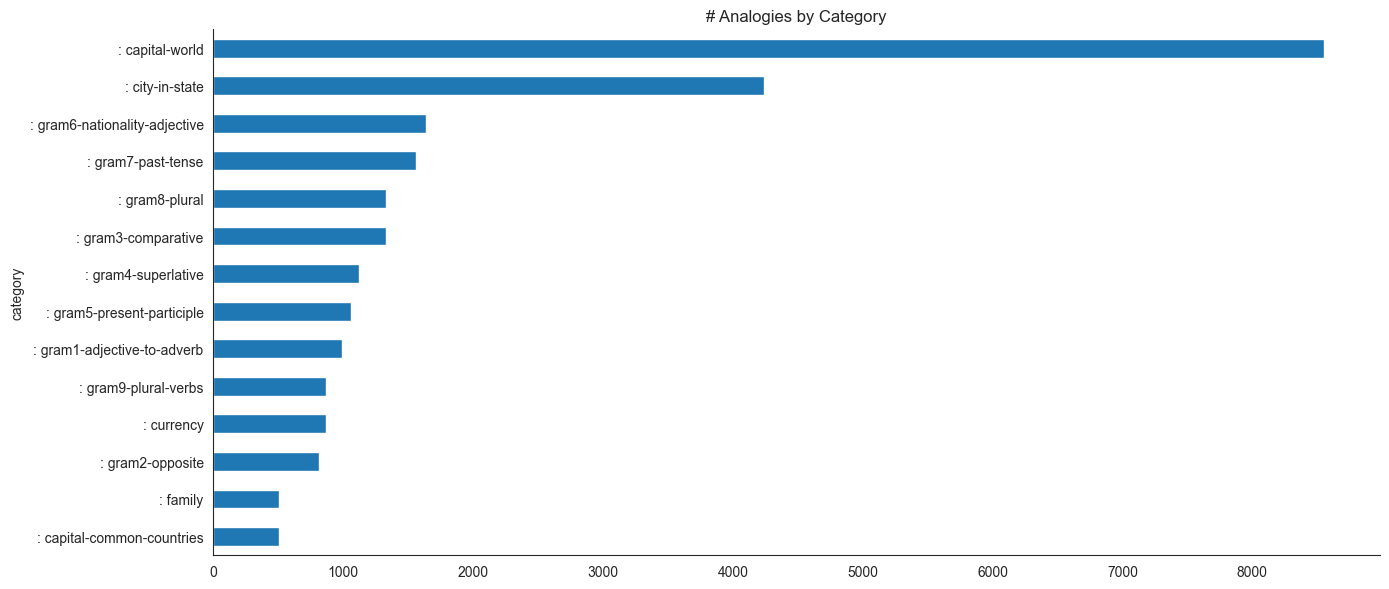

In [9]:
analogy_cnt.join(analogy_example)['n'].sort_values().plot.barh(title='# Analogies by Category',
                                                               figsize=(14, 6))
sns.despine()
plt.tight_layout()

## Final conclusion and critical discussion

The notebook now correctly parses the analogy file into a clean dataframe with the columns `category`, `a`, `b`, `c`, and `d`. The first rows confirm that the semantic structure has been preserved: for example, `athens : greece = baghdad : iraq` is correctly assigned to the `: capital-common-countries` category. The column check also confirms that the earlier duplication problem has been solved.

The descriptive analysis reveals a strong imbalance across categories. The largest category is `: capital-world`, with 8,556 examples, followed by `: city-in-state`, with 4,242 examples. By contrast, categories such as `: capital-common-countries` and `: family` contain only 506 examples each. This matters because a single aggregate accuracy score would be heavily influenced by the largest geographic categories. A model could perform very well on capital-country relations and still perform poorly on grammatical or family relations, while the global score might hide this weakness.

The benchmark also mixes different types of linguistic structure. Some categories are primarily semantic, such as capitals, currencies, and family relations. Others are more syntactic or morphological, such as plural forms, past tense, comparative adjectives, and superlatives. These groups should be interpreted separately. Strong performance on grammatical analogies does not necessarily imply strong semantic representation, and vice versa.

A further limitation is that analogy evaluation tests a very specific hypothesis: that a relation can be recovered through approximately linear vector arithmetic. This is a useful property, but it is not equivalent to general language understanding. Embeddings may be useful for many downstream tasks even if they do not perform perfectly on analogy questions. Conversely, good analogy performance may reflect frequency effects, dataset regularities, or memorized distributional patterns rather than robust conceptual reasoning.

The next natural step would be to load one or more pretrained embedding models and evaluate them category by category. For every analogy `a : b = c : d`, the model would compute a candidate vector such as `b - a + c`, retrieve the nearest word, and compare it with the expected answer `d`. The most informative output would not be only an overall accuracy, but a table of accuracies by category, together with examples of successful and failed analogies. That would make it possible to understand not merely whether an embedding model works, but where and why it works.
